In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE

 DATA QUALITY CHECKS

In [ ]:
df = pd.read_csv("HR_comma_sep.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df["left"].value_counts(normalize=True))

(14999, 10)
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  sales  \
0                   3              0     1                      0  sales   
1                   6              0     1                      0  sales   
2                   4              0     1                      0  sales   
3                   5              0     1                      0  sales   
4                   3              0     1                      0  sales   

   salary  
0     low  
1  medium  
2  medium  
3 

EDA: FACTORS CONTRIBUTING TO EMPLOYEE TURNOVER


Correlation Heatmap


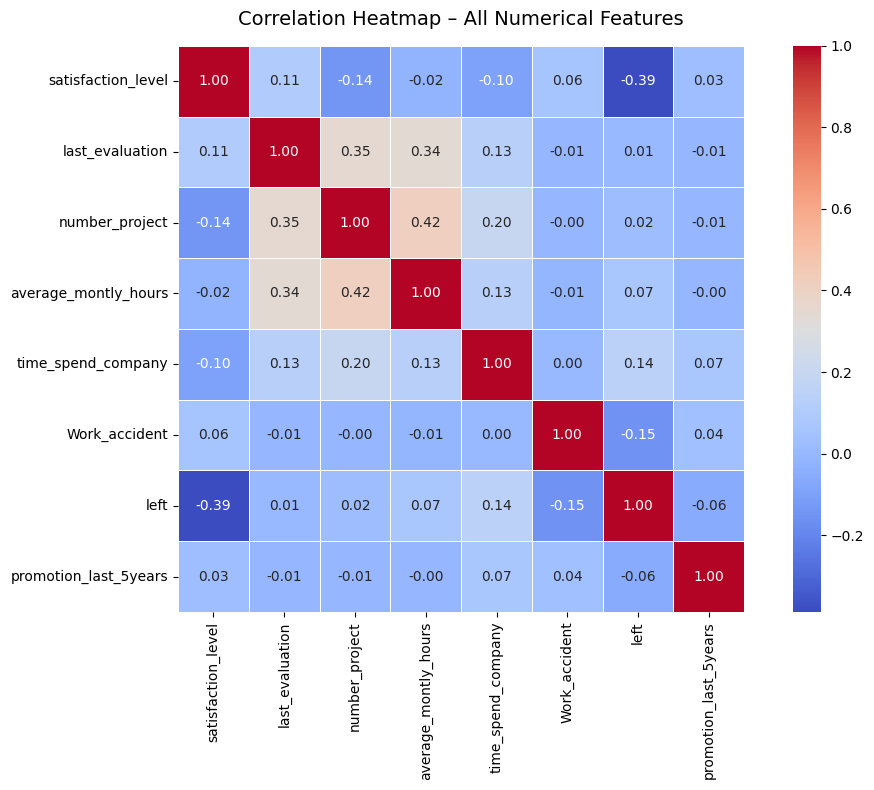

In [ ]:
# Correlation Heatmap (all numeric features)
print("\nCorrelation Heatmap")
plt.figure(figsize=(11, 8))
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Correlation Heatmap – All Numerical Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()



Distribution Plots


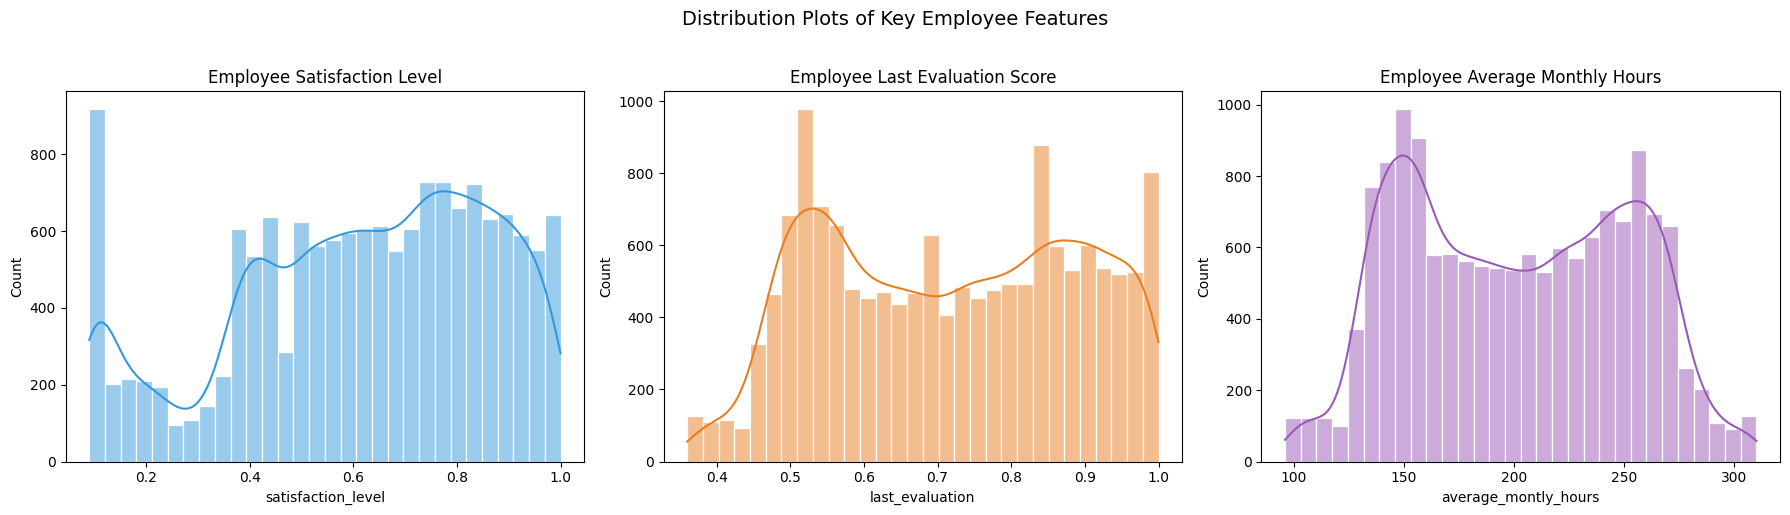

In [ ]:
# Distribution Plots: satisfaction, evaluation, monthly hours
print("\nDistribution Plots")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dist_config = [
    ("satisfaction_level",   "Employee Satisfaction Level",      "#3498db"),
    ("last_evaluation",      "Employee Last Evaluation Score",   "#e67e22"),
    ("average_montly_hours", "Employee Average Monthly Hours",   "#9b59b6"),
]

for ax, (col, title, color) in zip(axes, dist_config):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=30, edgecolor="white")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.suptitle("Distribution Plots of Key Employee Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



Bar Plot – Number of Projects by Left/Stayed


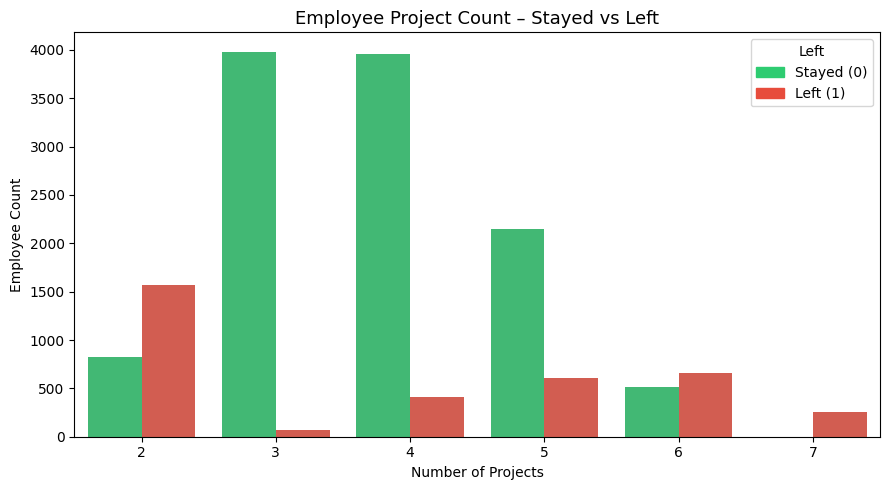

In [ ]:
# Bar plot: Project Count vs Left/Stayed
print("\nBar Plot – Number of Projects by Left/Stayed")

plt.figure(figsize=(9, 5))
ax = sns.countplot(x="number_project", hue="left", data=df,
                   palette={0: "#2ecc71", 1: "#e74c3c"})
ax.set_title("Employee Project Count – Stayed vs Left", fontsize=13)
ax.set_xlabel("Number of Projects")
ax.set_ylabel("Employee Count")
handles = [mpatches.Patch(color="#2ecc71", label="Stayed (0)"),
           mpatches.Patch(color="#e74c3c", label="Left (1)")]
ax.legend(handles=handles, title="Left")
plt.tight_layout()
plt.show()

INFERENCES from Project Count Bar Plot:


1.   Employees with 2 projects:   Highest attrition — likely
    under-utilized or disengaged with minimal workload.
2.   Employees with 3–4 projects: Lowest attrition — optimal
    workload; employees feel engaged and productive.


1.   Employees with 5–6 projects: Turnover rises again — signs
    of overwork and burnout increasing attrition risk.
2.  Employees with 7 projects:   Near-complete attrition — extreme
    overload; almost all employees at this level left.


  CONCLUSION: Both under-utilization and overwork drive turnover.
  The sweet spot for retention is 3–4 projects per employee.

K-MEANS CLUSTERING OF EMPLOYEES WHO LEFT

In [ ]:
# Select required columns and filter to employees who left
cluster_df = df[["satisfaction_level", "last_evaluation", "left"]].copy()
left_df    = cluster_df[cluster_df["left"] == 1][["satisfaction_level", "last_evaluation"]].copy()
print(f"Total employees who left: {len(left_df)}")

Total employees who left: 3571


In [ ]:
# K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
left_df["cluster"] = kmeans.fit_predict(left_df)

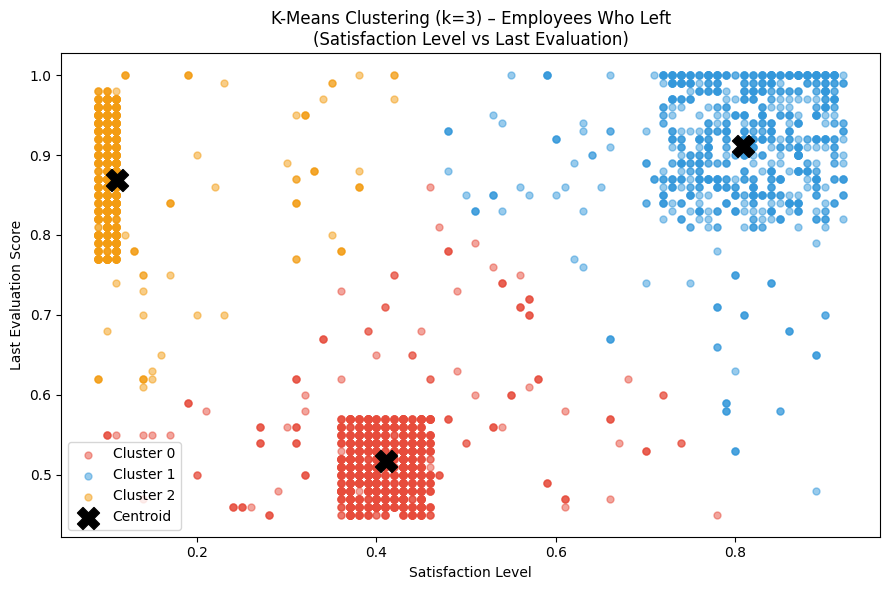


── Cluster Centroids & Sizes ──
 satisfaction_level  last_evaluation  cluster  size
              0.410            0.517        0  1650
              0.809            0.912        1   977
              0.111            0.869        2   944


In [ ]:
# Scatter plot
colors     = ["#e74c3c", "#3498db", "#f39c12"]
cluster_labels_map = {0: "Cluster 0", 1: "Cluster 1", 2: "Cluster 2"}

plt.figure(figsize=(9, 6))
for c in sorted(left_df["cluster"].unique()):
    subset = left_df[left_df["cluster"] == c]
    plt.scatter(subset["satisfaction_level"], subset["last_evaluation"],
                label=cluster_labels_map[c], alpha=0.5, s=25, color=colors[c])
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker="X", s=250, c="black", zorder=10, label="Centroid")
plt.title("K-Means Clustering (k=3) – Employees Who Left\n(Satisfaction Level vs Last Evaluation)", fontsize=12)
plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation Score")
plt.legend()
plt.tight_layout()
plt.show()

print("\n── Cluster Centroids & Sizes ──")
centroid_df = pd.DataFrame(centroids, columns=["satisfaction_level", "last_evaluation"]).round(3)
centroid_df["cluster"] = centroid_df.index
centroid_df["size"]    = left_df["cluster"].value_counts().sort_index().values
print(centroid_df.to_string(index=False))

CLUSTER THOUGHTS:


*   Cluster A – LOW satisfaction + HIGH evaluation:
      These are high performers who are overworked or under-
      rewarded. Despite strong evaluation scores, their very low
      satisfaction suggests burnout, lack of recognition, or
      unmet promotion expectations. Immediate action needed.
*   Cluster B – LOW satisfaction + LOW evaluation:
      Disengaged underperformers. Poor evaluation combined with
      low satisfaction indicates a culture/role mismatch or lack
      of support. These employees may have mentally quit before
      physically leaving.

*   Cluster C – MEDIUM satisfaction + MEDIUM-HIGH evaluation:
      Average performers with moderate satisfaction. They likely
      left due to better external opportunities or stagnation.
      Career growth programs and compensation benchmarking could
      have retained them.

PREPROCESSING + SMOTE

In [ ]:
# Identify categorical and numeric columns
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "left"]
print(f"Categorical columns : {cat_cols}")
print(f"Numeric columns     : {num_cols}")

Categorical columns : ['sales', 'salary']
Numeric columns     : ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


In [ ]:
# Apply get_dummies() to categorical columns
cat_dummies = pd.get_dummies(df[cat_cols], drop_first=False)
print(f"\nAfter get_dummies shape: {cat_dummies.shape}")
print(f"Dummy columns: {list(cat_dummies.columns)}")


After get_dummies shape: (14999, 13)
Dummy columns: ['sales_IT', 'sales_RandD', 'sales_accounting', 'sales_hr', 'sales_management', 'sales_marketing', 'sales_product_mng', 'sales_sales', 'sales_support', 'sales_technical', 'salary_high', 'salary_low', 'salary_medium']


In [ ]:
# Combine numeric + dummy encoded categorical
df_processed = pd.concat([df[num_cols], cat_dummies], axis=1)
print(f"\nFinal processed dataframe shape: {df_processed.shape}")

X = df_processed
y = df["left"]

print(f"\nClass distribution BEFORE SMOTE:\n{y.value_counts().to_dict()}")
print(f"Class imbalance ratio: {y.value_counts()[0]}:{y.value_counts()[1]} "
      f"= {(y.value_counts()[0]/y.value_counts()[1]):.2f}:1")


Final processed dataframe shape: (14999, 20)

Class distribution BEFORE SMOTE:
{0: 11428, 1: 3571}
Class imbalance ratio: 11428:3571 = 3.20:1


In [ ]:
# Stratified 80:20 split with random_state=123
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train class dist: {y_train.value_counts().to_dict()}")


Train size: (11999, 20), Test size: (3000, 20)
Train class dist: {0: 9142, 1: 2857}


In [ ]:
# SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE – Train class dist: {pd.Series(y_train_res).value_counts().to_dict()}")
print("SMOTE applied only on training data — no data leakage into test set.")

feature_cols = list(X.columns)


After SMOTE – Train class dist: {0: 9142, 1: 9142}
SMOTE applied only on training data — no data leakage into test set.


5-FOLD CROSS-VALIDATION + MODEL TRAINING

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                        max_depth=4, subsample=0.8, random_state=42),
}

results    = {}
pred_store = {}

for name, model in models.items():
    print(f"\n{'─'*55}")
    print(f"  Training: {name}")
    print(f"{'─'*55}")

    model.fit(X_train_res, y_train_res)

    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    cv_auc = cross_val_score(model, X_train_res, y_train_res, cv=skf, scoring="roc_auc")
    cv_f1  = cross_val_score(model, X_train_res, y_train_res, cv=skf, scoring="f1")

    print(f"\n  Classification Report – {name}:")
    print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))
    print(f"  5-Fold CV AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
    print(f"  5-Fold CV F1  : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}")

    results[name] = {
        "model"       : model,
        "y_pred"      : y_pred,
        "y_pred_prob" : y_pred_prob,
        "test_auc"    : roc_auc_score(y_test, y_pred_prob),
        "cv_auc_mean" : cv_auc.mean(),
        "cv_auc_std"  : cv_auc.std(),
        "cv_f1_mean"  : cv_f1.mean(),
    }


───────────────────────────────────────────────────────
  Training: Logistic Regression
───────────────────────────────────────────────────────

  Classification Report – Logistic Regression:
              precision    recall  f1-score   support

      Stayed       0.90      0.80      0.85      2286
        Left       0.53      0.72      0.61       714

    accuracy                           0.78      3000
   macro avg       0.72      0.76      0.73      3000
weighted avg       0.81      0.78      0.79      3000

  5-Fold CV AUC : 0.8814 ± 0.0049
  5-Fold CV F1  : 0.8089  ± 0.0055

───────────────────────────────────────────────────────
  Training: Random Forest
───────────────────────────────────────────────────────

  Classification Report – Random Forest:
              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99      2286
        Left       0.97      0.98      0.97       714

    accuracy                           0.99      3000
   macro avg

BEST MODEL IDENTIFICATION & METRIC JUSTIFICATION


ROC / AUC Scores & ROC Curve


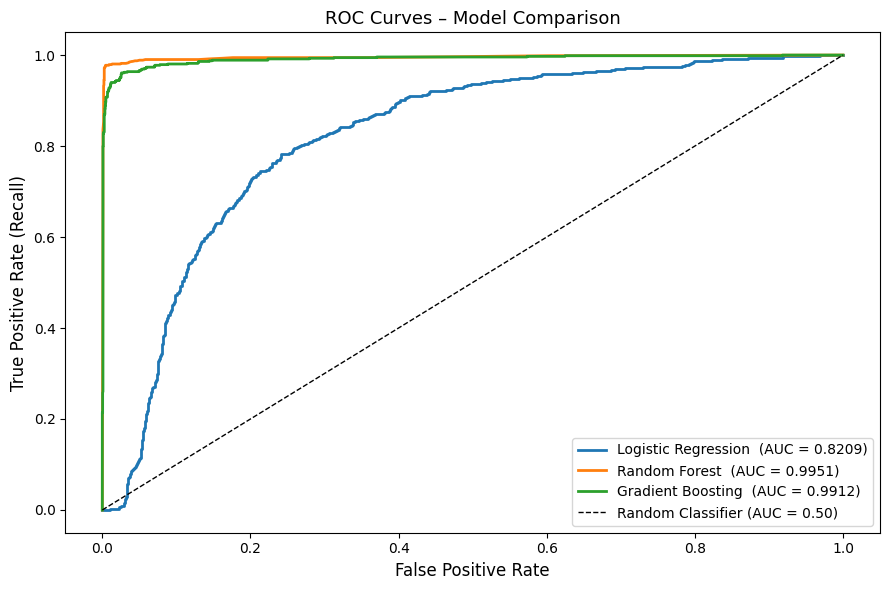

In [ ]:
# ROC/AUC for each model + ROC Curve plot
print("\nROC / AUC Scores & ROC Curve")

plt.figure(figsize=(9, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_pred_prob"])
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{name}  (AUC = {res['test_auc']:.4f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier (AUC = 0.50)")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curves – Model Comparison", fontsize=13)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()



Confusion Matrices


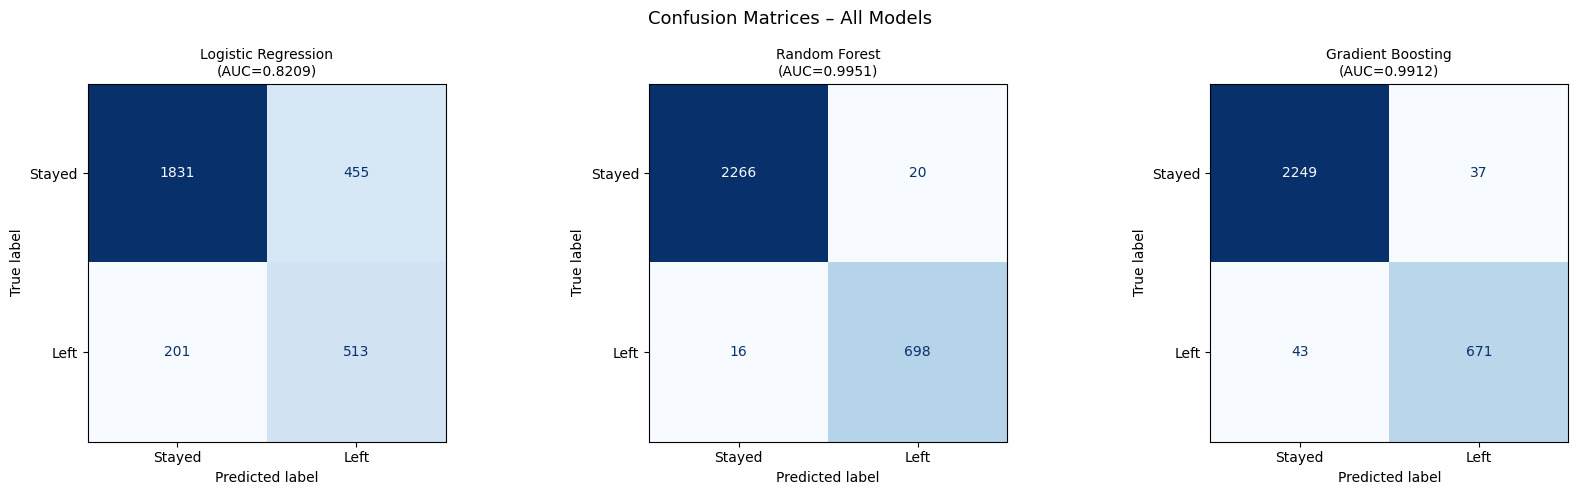

In [ ]:
# Confusion Matrix for each model
print("\nConfusion Matrices")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Left"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\n(AUC={res['test_auc']:.4f})", fontsize=10)
plt.suptitle("Confusion Matrices – All Models", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Model Comparison Table
print("\nModel Comparison Summary")
comparison = pd.DataFrame({
    "Model"        : list(results.keys()),
    "Test AUC"     : [r["test_auc"]    for r in results.values()],
    "CV AUC Mean"  : [r["cv_auc_mean"] for r in results.values()],
    "CV AUC Std"   : [r["cv_auc_std"]  for r in results.values()],
    "CV F1 Mean"   : [r["cv_f1_mean"]  for r in results.values()],
}).round(4)
print(comparison.to_string(index=False))

best_name = max(results, key=lambda k: results[k]["test_auc"])
print(f"\nBEST MODEL: {best_name}  (Test AUC = {results[best_name]['test_auc']:.4f})")


Model Comparison Summary
              Model  Test AUC  CV AUC Mean  CV AUC Std  CV F1 Mean
Logistic Regression    0.8209       0.8814      0.0049      0.8089
      Random Forest    0.9951       0.9977      0.0003      0.9842
  Gradient Boosting    0.9912       0.9967      0.0003      0.9775

BEST MODEL: Random Forest  (Test AUC = 0.9951)


METRIC JUSTIFICATION

  PRIMARY METRIC → ROC-AUC


1.   The dataset is class-imbalanced (~76% stayed, ~24% left).
    Accuracy would be misleading — a dummy model predicting
    "everyone stays" achieves ~76% accuracy with zero utility.
2.   ROC-AUC captures model discrimination power across ALL
    classification thresholds and is robust to class imbalance.

1.   Higher AUC = better ability to rank high-risk employees above
    low-risk ones, which is exactly what HR needs.


  RECALL vs PRECISION FROM CONFUSION MATRIX:

  RECALL is the preferred metric for this problem.


*   False Negative = predicting "Stay" when employee      
     will actually LEAVE → the most costly error.          
     HR misses a flight-risk employee entirely.
*    False Positive = predicting "Leave" when employee     
     actually stays → HR checks in unnecessarily, which    
     is a low-cost mistake.


*  Therefore, MAXIMISING RECALL (sensitivity) for the    
     "Left" class is the business priority — catch as      
     many at-risk employees as possible, even at the cost  
     of some false alarms.



RISK ZONES + RETENTION STRATEGIES

In [ ]:
best_model    = results[best_name]["model"]
best_probs    = results[best_name]["y_pred_prob"]

def assign_risk_zone(prob):
    """
    Green  (Safe)        : prob < 0.20
    Yellow (Low-Risk)    : 0.20 <= prob < 0.60
    Orange (Medium-Risk) : 0.60 <= prob < 0.90
    Red    (High-Risk)   : prob >= 0.90
    """
    if prob < 0.20:
        return "Safe Zone (Green)"
    elif prob < 0.60:
        return "Low-Risk Zone (Yellow)"
    elif prob < 0.90:
        return "Medium-Risk Zone (Orange)"
    else:
        return "High-Risk Zone (Red)"

results_df = X_test.copy()
results_df["actual"]         = y_test.values
results_df["attrition_prob"] = (best_probs * 100).round(2)   # as percentage
results_df["risk_zone"]      = best_probs
results_df["risk_zone"]      = results_df["risk_zone"].apply(assign_risk_zone)

print(f"\nBest model used: {best_name}")
print("\nRisk Zone Distribution:")
zone_counts = results_df["risk_zone"].value_counts()
print(zone_counts)

print("\nSample Predictions (first 15 rows):")
print(results_df[["satisfaction_level", "average_montly_hours",
                   "attrition_prob", "risk_zone", "actual"]].head(15).to_string())


Best model used: Random Forest

Risk Zone Distribution:
risk_zone
Safe Zone (Green)            2179
High-Risk Zone (Red)          649
Low-Risk Zone (Yellow)        113
Medium-Risk Zone (Orange)      59
Name: count, dtype: int64

Sample Predictions (first 15 rows):
       satisfaction_level  average_montly_hours  attrition_prob               risk_zone  actual
10627                0.98                   191             0.0       Safe Zone (Green)       0
2703                 0.76                   271            59.0  Low-Risk Zone (Yellow)       0
6059                 0.70                   185             4.0       Safe Zone (Green)       0
3258                 0.48                   223             0.0       Safe Zone (Green)       0
4565                 0.57                   144             1.0       Safe Zone (Green)       0
4991                 0.79                    98             0.0       Safe Zone (Green)       0
13976                0.92                   190             1.

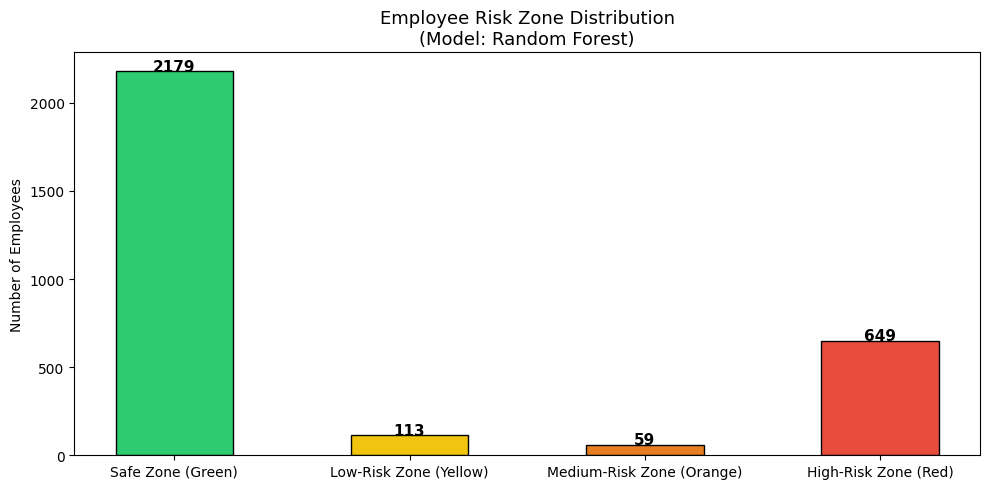

In [ ]:
# Risk Zone Bar Chart
zone_order  = ["Safe Zone (Green)", "Low-Risk Zone (Yellow)",
               "Medium-Risk Zone (Orange)", "High-Risk Zone (Red)"]
zone_colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
counts      = results_df["risk_zone"].value_counts().reindex(zone_order).fillna(0).astype(int)

plt.figure(figsize=(10, 5))
bars = plt.bar(zone_order, counts.values, color=zone_colors, edgecolor="black", width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 3, str(val), ha="center", fontsize=11, fontweight="bold")
plt.title(f"Employee Risk Zone Distribution\n(Model: {best_name})", fontsize=13)
plt.ylabel("Number of Employees")
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()


RETENTION STRATEGIES BY RISK ZONE

SAFE ZONE (Score < 20%) — Low attrition probability

1.   These employees are satisfied and engaged. Focus on sustaining
    their positive experience.
2.   Actions:
      – Annual performance bonuses and merit-based increments
      – Long-term incentive plans (ESOPs, profit sharing)
      – Internal mobility and cross-functional opportunities
      – Public recognition and awards programs
      – Periodic check-ins to ensure continued engagement

LOW-RISK ZONE (20% – 60%) — Moderate attrition probability



1.   These employees show early signs of dissatisfaction. Proactive
    engagement can prevent escalation.
2.   Actions:
      – Quarterly 1-on-1 career development conversations
      – Skill-building workshops and certification support
      – Mentoring programs and peer recognition platforms
      – Flexible work arrangements (hybrid/remote options)
      – Team-building activities to improve belonging

MEDIUM-RISK ZONE (60% – 90%) — High attrition probability



1.   These employees are actively considering leaving. Urgent
    targeted intervention is required.
2.   Actions:
      – Immediate manager-led 1-on-1 satisfaction discussion
      – Workload audit — check if overloaded (hours > 220/month)
      – Salary benchmarking vs market rates; offer adjustment
      – Offer role change, lateral move, or new project ownership
      – Fast-track promotion review for high evaluators
      – Address specific grievances identified in conversation


HIGH-RISK ZONE (Score > 90%) — Critical attrition risk



1.   Imminent flight risk. HR and senior leadership must act
    immediately — every day without action increases exit chance.
2.   Actions:
      – Executive-level retention conversation within 48 hours
      – Personalised retention package (compensation + role + title)
      – Mandatory workload redistribution if overloaded
      – Offer sabbatical or leave of absence if burnout is detected
      – If departure cannot be prevented — begin knowledge transfer
        and structured offboarding to minimise business disruption
      – Conduct root cause analysis to prevent pattern replication


CLUSTER-BASED STRATEGIES


1.   Cluster A (Low satisfaction, High evaluation — Overworked stars):
      → Promote, raise compensation, reduce project load immediately

1.   Cluster B (Low satisfaction, Low evaluation — Disengaged):
      → Performance coaching, role realignment, culture fit review
2.   Cluster C (Medium satisfaction, Medium evaluation — Stagnant):
      → Structured growth roadmap, clear KPIs, mentorship program








